In [1]:
import pycisTopic
import dill
from pycisTopic.diff_features import (
    impute_accessibility,
    normalize_scores,
    find_highly_variable_features,
    find_diff_features
)
import numpy as np

from pycisTopic.clust_vis import (
    find_clusters,
    run_umap,
    run_tsne,
    plot_metadata,
    plot_topic,
    cell_topic_heatmap
)

from pycisTopic.gene_annotation import (
    get_chrom_sizes_and_alias_mapping_from_ucsc
)
import pickle
import tempfile
import os
import pyranges as pr
from pycisTopic.gene_activity import get_gene_activity
from pycisTopic.lda_models import evaluate_models

lustre_path='/lustre/scratch127/cellgen/cellgeni/tickets/' + os.getcwd().split('/')[4]
lustre_path

/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-06-20 19:41:12,890	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


'/lustre/scratch127/cellgen/cellgeni/tickets/tic-3942'

# Impute

In [2]:
ntopics=[2,5,10,15,20,25,30,35,40,45,50,55]
models = []
for i in range(len(ntopics)):
    with open(lustre_path+'/work/pycistopic/results_pycistopic_call_peaks/mallet_models/model_'+str(ntopics[i])+'.pkl', "rb") as f:
        models.append(dill.load(f)[0])

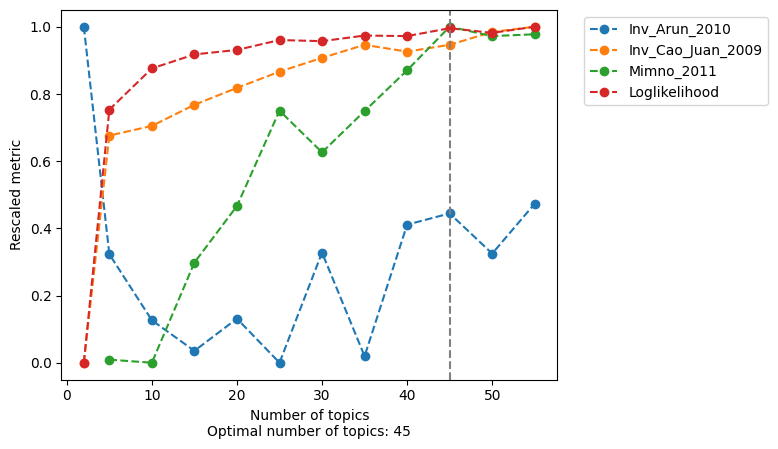

In [3]:
model = evaluate_models(
    models,
    select_model = 45,
    return_model = True
)

In [4]:
del models
with open(lustre_path+'/work/pycistopic/results_pycistopic_call_peaks/combined_cistopic_object.pkl', "rb") as f:
        cistopic_obj = dill.load(f)
cistopic_obj.add_LDA_model(model)
cistopic_obj

In [5]:
imputed_acc_obj = impute_accessibility(
    cistopic_obj,
    selected_cells=None,
    selected_regions=None,
    scale_factor=10**6
)

2025-06-20 19:42:57,581 cisTopic     INFO     Imputing region accessibility
2025-06-20 19:42:57,582 cisTopic     INFO     Impute region accessibility for regions 0-20000
2025-06-20 19:43:06,986 cisTopic     INFO     Impute region accessibility for regions 20000-40000
2025-06-20 19:43:23,338 cisTopic     INFO     Impute region accessibility for regions 40000-60000
2025-06-20 19:43:35,314 cisTopic     INFO     Impute region accessibility for regions 60000-80000
2025-06-20 19:43:48,070 cisTopic     INFO     Impute region accessibility for regions 80000-100000
2025-06-20 19:44:01,186 cisTopic     INFO     Impute region accessibility for regions 100000-120000
2025-06-20 19:44:13,890 cisTopic     INFO     Impute region accessibility for regions 120000-140000
2025-06-20 19:46:17,781 cisTopic     INFO     Impute region accessibility for regions 140000-160000
2025-06-20 19:46:51,728 cisTopic     INFO     Impute region accessibility for regions 160000-180000
2025-06-20 19:47:01,841 cisTopic     

# DARs

In [ ]:
normalized_imputed_acc_obj = normalize_scores(imputed_acc_obj, scale_factor=10**4)

2025-06-20 19:51:13,152 cisTopic     INFO     Normalizing imputed data


In [ ]:
variable_regions = find_highly_variable_features(
    normalized_imputed_acc_obj,
    min_disp = 0.05,
    min_mean = 0.0125,
    max_mean = 3,
    max_disp = np.inf,
    n_bins=20,
    n_top_features=None,
    plot=True
)

In [ ]:
len(variable_regions)

In [ ]:
import tempfile
tmp_path = tempfile.mkdtemp()
contrast = [
    [['Granulosa_sq'],['Granulosa_sq_transitioning','Granulosa_AMH_early','Granulosa_AMH_ml','Granulosa_sq_atr']],
    [['Granulosa_sq'],['Granulosa_sq_transitioning','Granulosa_AMH_early','Granulosa_AMH_ml']],
    [['Granulosa_sq'],['Granulosa_sq_transitioning']],
    [['Granulosa_sq'],['Granulosa_AMH_early']],
    [['Granulosa_sq'],['Granulosa_AMH_ml']],
    [['Granulosa_sq'],['Granulosa_sq_atr']]
]
markers_dict= find_diff_features(
    cistopic_obj,
    imputed_acc_obj,
    variable='',
    var_features=variable_regions,
    contrasts=contrast,
    adjpval_thr=0.05,
    log2fc_thr=np.log2(1.5),
    n_cpu=16,
    _temp_dir=tmp_path,
    split_pattern = '-'
)